<a href="https://colab.research.google.com/github/EduardoShoiti/pos-tech-ai-scientist/blob/main/Fase1/Desafio_Payflow/Pos_Tech_Desafio_Fase_1_PayFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
pd.options.display.max_columns = None

In [ ]:
df = pd.read_csv('payflow_credit_risk.csv')
df.head()

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,0.012,1,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,0.282,1,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,0.120,0,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,0.670,0,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,0.325,0,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0


In [ ]:
df.shape

(5000, 23)

In [ ]:
df.isnull().sum()

,0
id_cliente,0
idade,0
renda_mensal,192
tempo_emprego_anos,526
autonomo,0
score_credito,0
valor_solicitado,0
prazo_meses,0
juros_mensal_pct,0
qtde_cartoes,0


In [ ]:
# df["renda_missing"] = df["renda_mensal"].isna().astype(int)
# df["tempo_emprego_missing"] = df["tempo_emprego_anos"].isna().astype(int)

# df["renda_mensal"] = df["renda_mensal"].fillna(df["renda_mensal"].median())
# df["tempo_emprego_anos"] = df["tempo_emprego_anos"].fillna(df["tempo_emprego_anos"].median())

df_analise = df.copy()

In [ ]:
df_analise["faixa_idade"] = pd.cut(
    df_analise["idade"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

df_analise["faixa_juros_mensal_pct"] = pd.cut(
    df_analise["juros_mensal_pct"],
    bins=[0, 1, 2, 3, 4, 5, 6, 7, 8],
    labels=["0-1", "1-2", "2-3", "3-4", "4-5", "5-6", "6-7", "+7"]
)

df_analise

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d,faixa_idade,faixa_juros_mensal_pct
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,0.012,1,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1,18-25,3-4
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,0.282,1,0,0,0,app,Sudeste,cartao,2,10,em_dia,0,56-65,3-4
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,0.120,0,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0,46-55,3-4
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,0.670,0,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0,36-45,1-2
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,0.325,0,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0,36-45,3-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,2546.31,4.518782,0,756.0,5267.45,12,1.83,1,2,0.645,0,0,0,0,parceiro,Sudeste,emprestimo_pessoal,2,10,em_atraso_leve,0,26-35,1-2
4996,4997,57,5188.43,12.239635,0,607.0,4334.45,12,3.56,0,2,0.258,1,0,1,0,app,Sudeste,emprestimo_pessoal,2,0,em_dia,0,56-65,3-4
4997,4998,61,1518.25,NaN,1,643.0,6925.45,18,2.54,0,1,0.413,2,90,1,0,app,Sudeste,cartao,1,97,default,1,56-65,2-3
4998,4999,53,3224.09,1.041160,0,643.0,3746.70,12,2.42,1,1,0.237,0,15,0,0,app,Sudeste,cartao,3,0,em_dia,0,46-55,2-3


Hipótese se os dados nulos estão vindo por conta do canal de aquisição

In [ ]:
df_analise[df_analise['renda_mensal'].isnull()]['canal_aquisicao'].value_counts()

,count
canal_aquisicao,
app,89
site,47
parceiro,29
loja,27


In [ ]:
df_analise[df_analise['tempo_emprego_anos'].isnull()]['canal_aquisicao'].value_counts()

,count
canal_aquisicao,
app,259
site,133
parceiro,74
loja,60


## EDA

### Volume de clientes X Taxa default

/tmp/ipykernel_1060/1422220652.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col, dropna=False)
/tmp/ipykernel_1060/1422220652.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col, dropna=False)


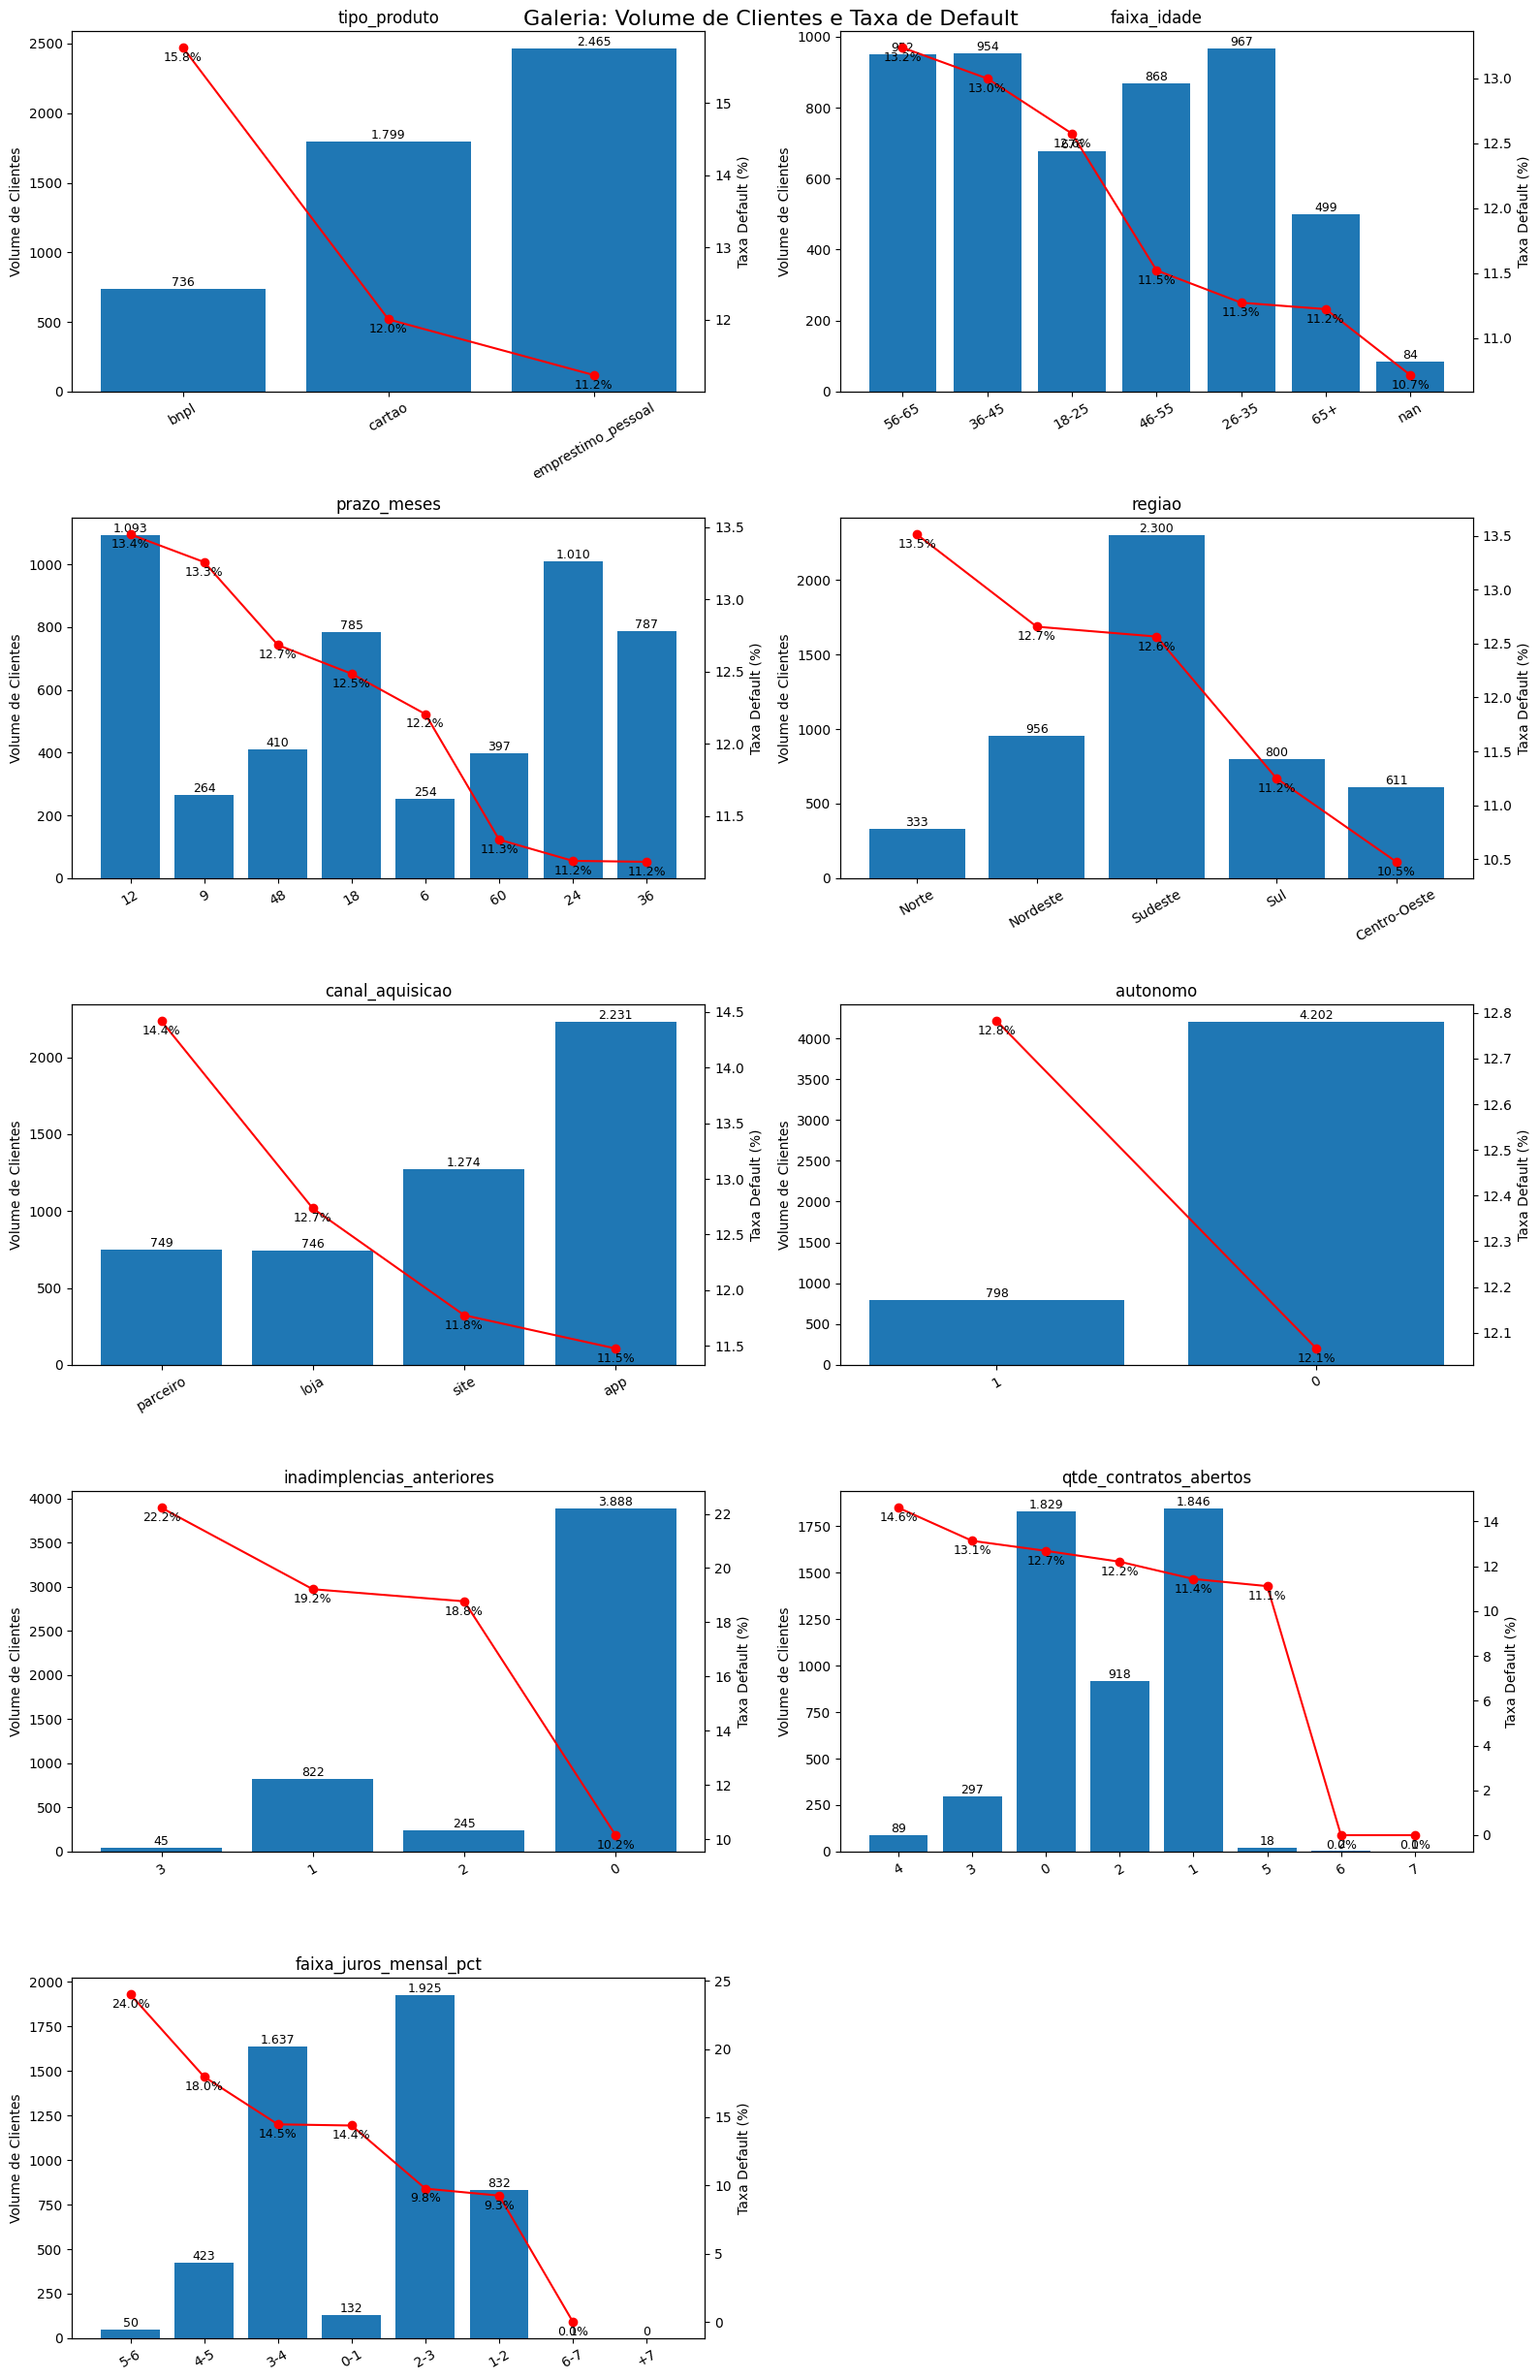

In [ ]:
def plot_gallery_volume_default(
    df,
    cols,
    target="default_90d",
    id_col="id_cliente",
    sort_by="volume",
    ascending=False,
    top_n=None,
    ncols=2,
    figsize_per_plot=(8, 5)
):
    n = len(cols)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)
    )

    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, col in zip(axes, cols):
        # agregação
        agg = (
            df.groupby(col, dropna=False)
              .agg(
                  volume_clientes=(id_col, "count"),
                  taxa_default=(target, "mean")
              )
              .reset_index()
        )

        agg[col] = agg[col].astype(str)
        agg["taxa_default_pct"] = agg["taxa_default"] * 100

        if sort_by == "volume":
            agg = agg.sort_values("volume_clientes", ascending=ascending)
        elif sort_by == "default":
            agg = agg.sort_values("taxa_default_pct", ascending=ascending)
        elif sort_by == "categoria":
            agg = agg.sort_values(col, ascending=ascending)

        if top_n is not None:
            agg = agg.head(top_n)

        # barra
        bars = ax.bar(agg[col], agg["volume_clientes"])
        ax.set_title(col)
        ax.set_ylabel("Volume de Clientes")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

        # linha
        ax2 = ax.twinx()
        ax2.plot(agg[col], agg["taxa_default_pct"], marker="o", color="red")
        ax2.set_ylabel("Taxa Default (%)")

        # labels da barra
        for bar, v in zip(bars, agg["volume_clientes"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{v:,.0f}".replace(",", "."),
                ha="center",
                va="bottom",
                fontsize=9
            )

        # labels da linha
        for i, y in enumerate(agg["taxa_default_pct"]):
            ax2.annotate(
                f"{y:.1f}%",
                (i, y),
                textcoords="offset points",
                xytext=(0, -10),
                ha="center",
                fontsize=9,
                color="black"
            )

    for i in range(len(cols), len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle("Galeria: Volume de Clientes e Taxa de Default", fontsize=16)
    plt.tight_layout()
    plt.show()

cols = ["tipo_produto", "faixa_idade", "prazo_meses", "regiao", "canal_aquisicao", "autonomo", "inadimplencias_anteriores", "qtde_contratos_abertos", "faixa_juros_mensal_pct"]
plot_gallery_volume_default(df_analise, cols, sort_by="default", ncols=2)

In [ ]:
df_analise

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d,faixa_idade,faixa_juros_mensal_pct
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,0.012,1,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1,18-25,3-4
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,0.282,1,0,0,0,app,Sudeste,cartao,2,10,em_dia,0,56-65,3-4
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,0.120,0,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0,46-55,3-4
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,0.670,0,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0,36-45,1-2
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,0.325,0,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0,36-45,3-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,2546.31,4.518782,0,756.0,5267.45,12,1.83,1,2,0.645,0,0,0,0,parceiro,Sudeste,emprestimo_pessoal,2,10,em_atraso_leve,0,26-35,1-2
4996,4997,57,5188.43,12.239635,0,607.0,4334.45,12,3.56,0,2,0.258,1,0,1,0,app,Sudeste,emprestimo_pessoal,2,0,em_dia,0,56-65,3-4
4997,4998,61,1518.25,NaN,1,643.0,6925.45,18,2.54,0,1,0.413,2,90,1,0,app,Sudeste,cartao,1,97,default,1,56-65,2-3
4998,4999,53,3224.09,1.041160,0,643.0,3746.70,12,2.42,1,1,0.237,0,15,0,0,app,Sudeste,cartao,3,0,em_dia,0,46-55,2-3


### Distribuição de Defaults (Renda vs Empréstimo)

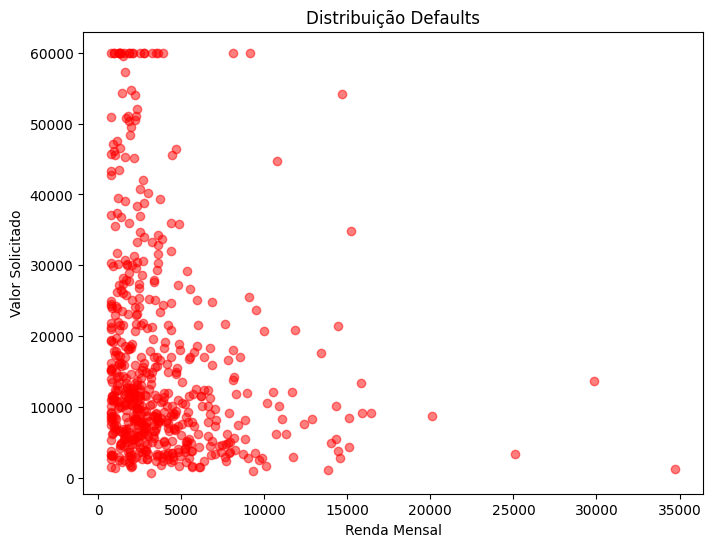

In [ ]:
plt.figure(figsize=(8,6))

# colors = df["default_90d"].map({0:"blue", 1:"red"})
df_default = df_analise[df_analise["default_90d"] == 1]

plt.scatter(
    df_default["renda_mensal"],
    df_default["valor_solicitado"],
    c="red",
    # c=colors,
    alpha=0.5
)

plt.xlabel("Renda Mensal")
plt.ylabel("Valor Solicitado")
plt.title("Distribuição Defaults")

plt.show()

In [ ]:
df_analise['renda_mensal'].describe()

,renda_mensal
count,4808.000000
mean,4692.966951
std,4005.355631
min,800.000000
25%,2136.475000
50%,3496.405000
75%,5863.252500
max,35000.000000


### Taxa de Default por Renda vs Empréstimo

/tmp/ipykernel_1060/3359975513.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_analise.pivot_table(


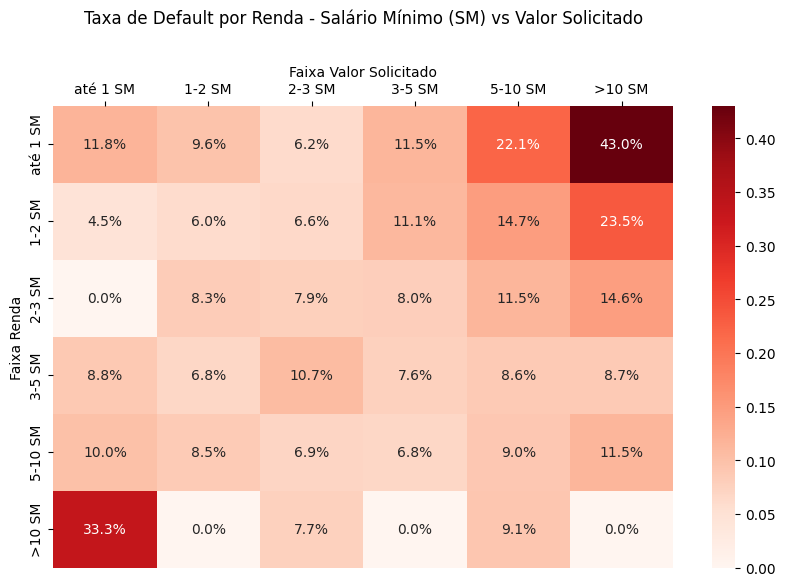

In [ ]:
salario_min = 1621

bins = [
    0,
    1621,
    3242,
    4863,
    8105,
    16210,
    float("inf")
]

labels = [
    "até 1 SM",
    "1-2 SM",
    "2-3 SM",
    "3-5 SM",
    "5-10 SM",
    ">10 SM"
]

df_analise["renda_bucket"] = pd.cut(
    df_analise["renda_mensal"],
    bins=bins,
    labels=labels
)


df_analise["valor_bucket"] = pd.cut(
    df_analise["valor_solicitado"],
    bins=bins,
    labels=labels
)

heatmap_data = df_analise.pivot_table(
    values="default_90d",
    index="renda_bucket",
    columns="valor_bucket",
    aggfunc="mean"
)
heatmap_data = heatmap_data.loc[
    ["até 1 SM","1-2 SM","2-3 SM","3-5 SM","5-10 SM",">10 SM"]
]

plt.figure(figsize=(10,6))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1%",
    cmap="Reds"
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xlabel("Faixa Valor Solicitado")
plt.ylabel("Faixa Renda")

plt.title("Taxa de Default por Renda - Salário Mínimo (SM) vs Valor Solicitado", pad=30)

plt.show()

In [ ]:
df_analise[
  (df_analise["renda_bucket"] == ">10 SM")
  & (df_analise["valor_bucket"] == "até 1 SM")
].groupby("default_90d").agg(
    volume_clientes=("id_cliente", "count")
)

,volume_clientes
default_90d,
0,2
1,1


### Taxa de Default por Loan Income (empréstimo / renda)

/tmp/ipykernel_1060/2923851642.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df_analise.groupby("lti_bucket")["default_90d"].mean()*100


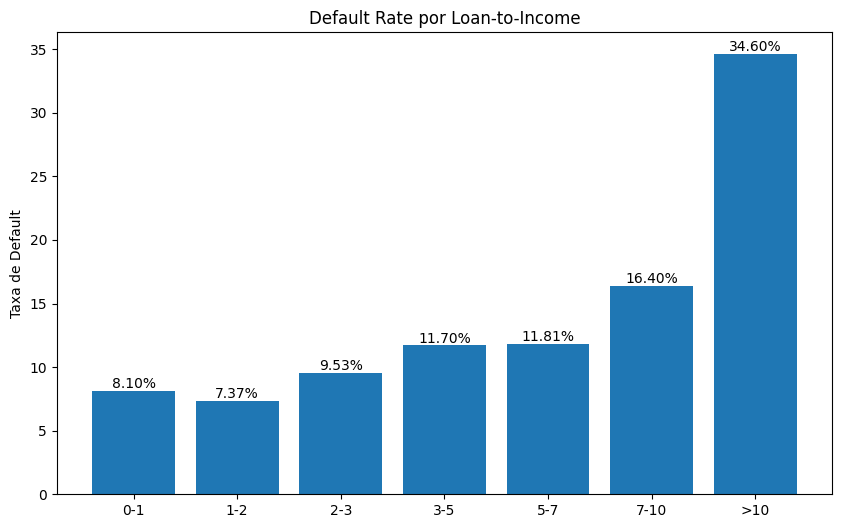

In [ ]:
bins = [
    0,
    1,
    2,
    3,
    5,
    7,
    10,
    float("inf")
]

labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-5",
    "5-7",
    "7-10",
    ">10"
]

df_analise["loan_to_income"] = df_analise["valor_solicitado"] / df_analise["renda_mensal"]

df_analise["lti_bucket"] = pd.cut(
    df_analise["loan_to_income"],
    bins=bins,
    labels=labels
)

default_rate = df_analise.groupby("lti_bucket")["default_90d"].mean()*100

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    default_rate.index,
    default_rate.values
)

for i, v in enumerate(default_rate):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom")

plt.ylabel("Taxa de Default")
plt.title("Default Rate por Loan-to-Income")
plt.show()

In [ ]:
df_analise.isnull().sum()

,0
id_cliente,0
idade,0
renda_mensal,192
tempo_emprego_anos,526
autonomo,0
score_credito,0
valor_solicitado,0
prazo_meses,0
juros_mensal_pct,0
qtde_cartoes,0


## Data Prepare

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df_tratado = df.copy()
df_tratado

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,0,0.012,1,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,2,0.282,1,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,2,0.120,0,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,3,0.670,0,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,0,0.325,0,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,2546.31,4.518782,0,756.0,5267.45,12,1.83,1,2,0.645,0,0,0,0,parceiro,Sudeste,emprestimo_pessoal,2,10,em_atraso_leve,0
4996,4997,57,5188.43,12.239635,0,607.0,4334.45,12,3.56,0,2,0.258,1,0,1,0,app,Sudeste,emprestimo_pessoal,2,0,em_dia,0
4997,4998,61,1518.25,NaN,1,643.0,6925.45,18,2.54,0,1,0.413,2,90,1,0,app,Sudeste,cartao,1,97,default,1
4998,4999,53,3224.09,1.041160,0,643.0,3746.70,12,2.42,1,1,0.237,0,15,0,0,app,Sudeste,cartao,3,0,em_dia,0


In [ ]:
df_tratado["loan_to_income"] = df_tratado["valor_solicitado"] / df_tratado["renda_mensal"]

In [ ]:
df_tratado = df_tratado.drop(columns=[
    "parcelas_pagas_ate_3m",
    "atraso_primeira_parcela_dias",
    "status_apos_90d"
])

In [ ]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 5000 non-null   int64  
 1   idade                      5000 non-null   int64  
 2   renda_mensal               4808 non-null   float64
 3   tempo_emprego_anos         4474 non-null   float64
 4   autonomo                   5000 non-null   int64  
 5   score_credito              5000 non-null   float64
 6   valor_solicitado           5000 non-null   float64
 7   prazo_meses                5000 non-null   int64  
 8   juros_mensal_pct           5000 non-null   float64
 9   qtde_cartoes               5000 non-null   int64  
 10  qtde_contratos_abertos     5000 non-null   int64  
 11  utilizacao_credito         5000 non-null   float64
 12  inadimplencias_anteriores  5000 non-null   int64  
 13  dias_atraso_max_12m        5000 non-null   int64

In [ ]:
print(df_tratado['canal_aquisicao'].value_counts())
print(df_tratado['regiao'].value_counts())
print(df_tratado['tipo_produto'].value_counts())

canal_aquisicao
app         2231
site        1274
parceiro     749
loja         746
Name: count, dtype: int64
regiao
Sudeste         2300
Nordeste         956
Sul              800
Centro-Oeste     611
Norte            333
Name: count, dtype: int64
tipo_produto
emprestimo_pessoal    2465
cartao                1799
bnpl                   736
Name: count, dtype: int64


In [ ]:
# encoder = OneHotEncoder()
# encoded = encoder.fit_transform(df[['canal_aquisicao', 'regiao', 'tipo_produto']])